In [2]:
import numpy as np

from model_ranking import plot_transfer_performance_heatmap
from model_ranking import get_summary_results, perf_results_to_array

# Unetr Results

In [2]:
source_datasets = ["EPFL", "Hmito", "Rmito"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model_Unetr2",
    "Hmito": "Hm_model_Unetr2",
    "Rmito": "Rm_model_Unetr2",
}
per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys=None
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 207.41it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 269.07it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 265.78it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 261.28it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 211.60it/s]


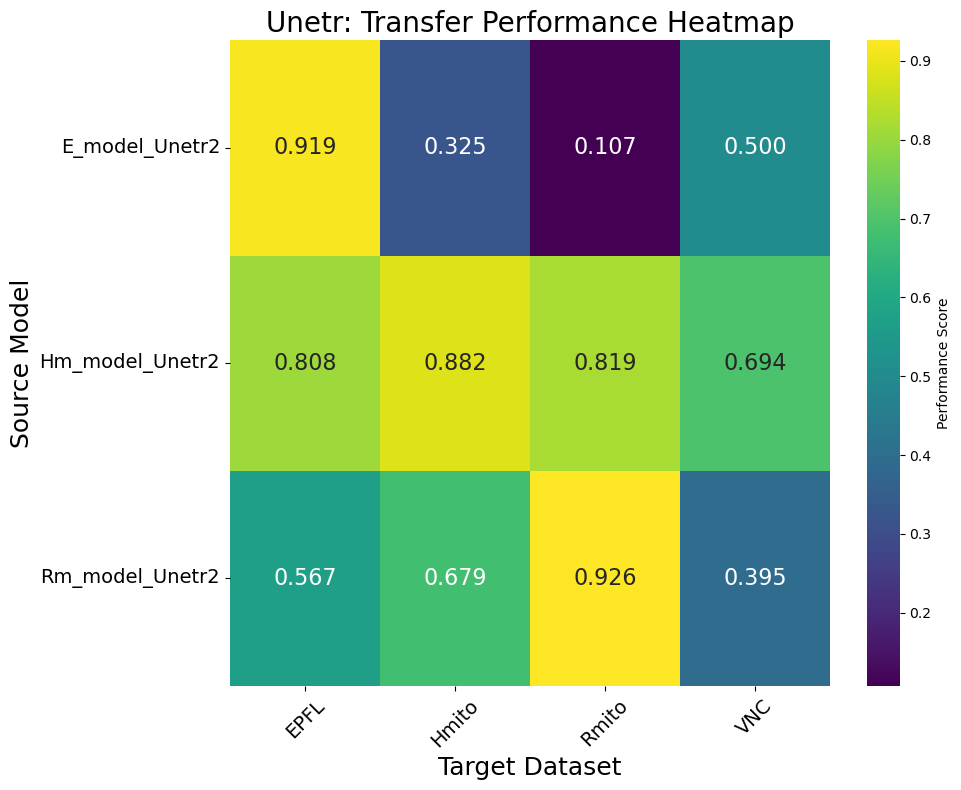

In [3]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    _, _, NA_perf = get_summary_results(
        source_data=["EPFL", "Hmito", "Rmito"],
        target_data=[target],
        source_models=source_models,
        selected_augmentations=None,
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets,
    title_prefix="Unetr:"
)

# Residual UNet 

In [4]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys=None
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 37.76it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 44.87it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 44.61it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 59.11it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 53.25it/s]


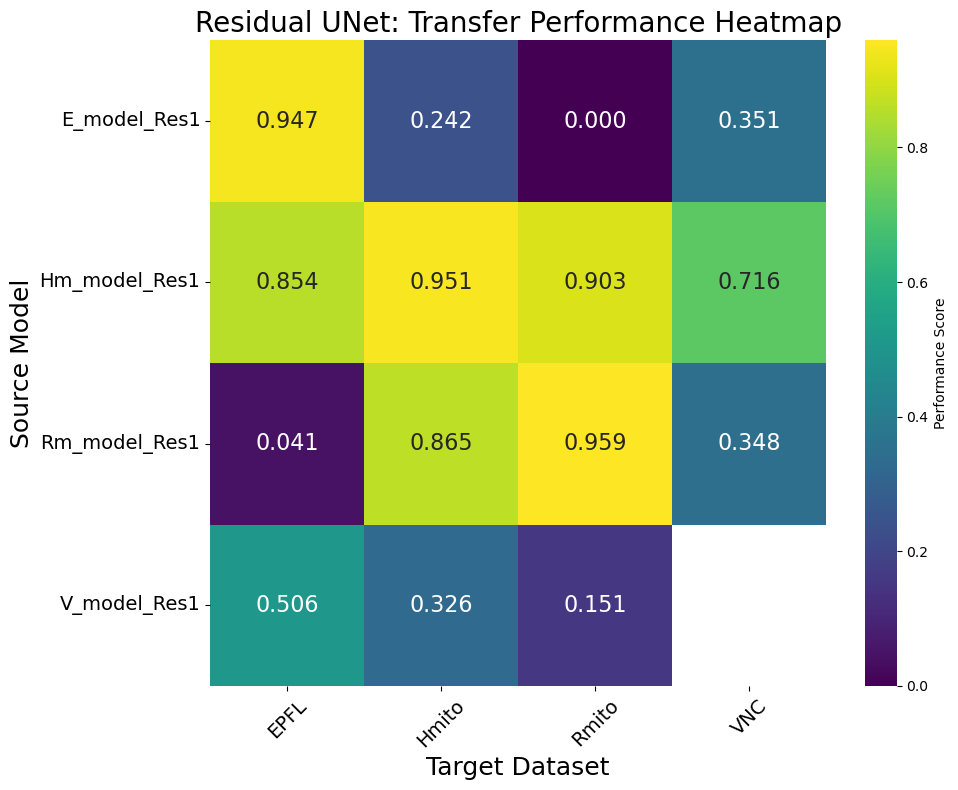

In [5]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    _, _, NA_perf = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models=source_models,
        selected_augmentations=None,
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    if target == "VNC":
        NA_perf_scores = np.append(NA_perf_scores, np.nan)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets,
    title_prefix="Residual UNet:"
)

# No Augment UNet

In [4]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys=None
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 59.27it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 75.58it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 73.95it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 73.17it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 69.29it/s]


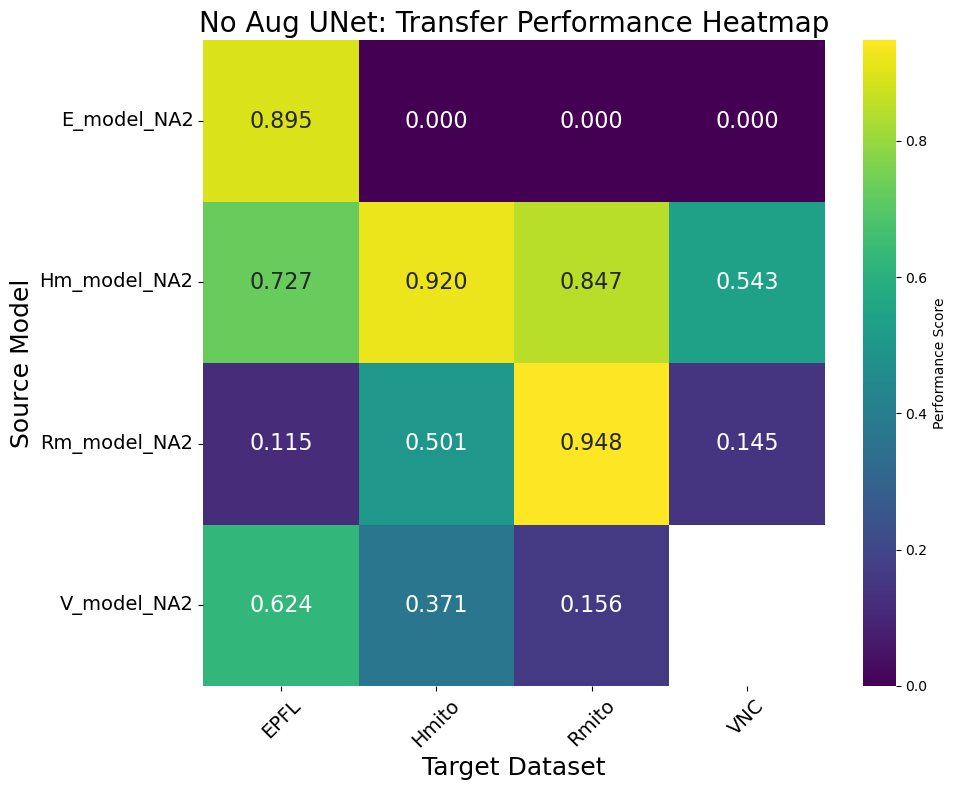

In [6]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    _, _, NA_perf = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models=source_models,
        selected_augmentations=None,
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    if target == "VNC":
        NA_perf_scores = np.append(NA_perf_scores, np.nan)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets,
    title_prefix="No Aug UNet:"
)

In [3]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model_NA1",
    "Hmito": "Hm_model_NA1",
    "Rmito": "Rm_model_NA1",
    "VNC": "V_model_NA1",
}
per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys=None
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 22.25it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 26.47it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 31.62it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 28.16it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 28.09it/s]


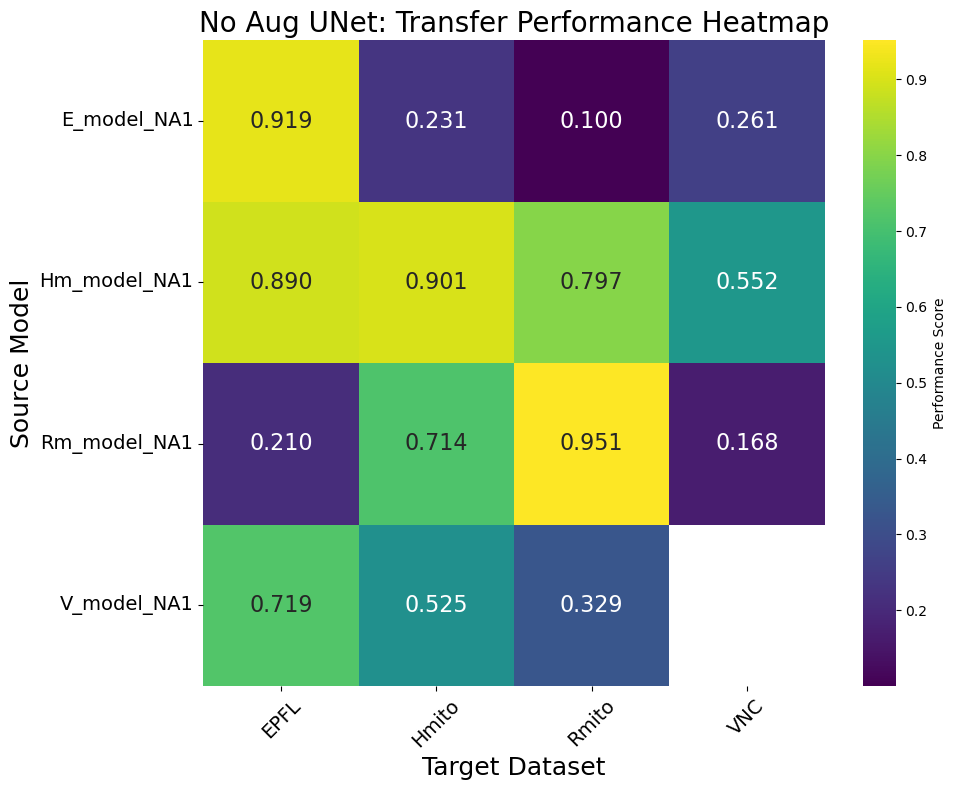

In [4]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    _, _, NA_perf = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models=source_models,
        selected_augmentations=None,
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    if target == "VNC":
        NA_perf_scores = np.append(NA_perf_scores, np.nan)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets,
    title_prefix="No Aug UNet:"
)

# UNet results (Global Normalisation)

In [10]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model5",
    "Hmito": "Hm_model4",
    "Rmito": "Rm_model4",
    "VNC": "V_model2",
}
per_target_norms = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
result_folders={
    "EPFL": "P_full",
    "Hmito": "P_full",
    "Rmito": "P_full",
    "VNC": "P_full",
}
consis_keys=None
perf_key = "hard_f1"
approach="consistency"
consis_postfix="median"
perf_postfix="median"
summary_results_postfix = "_full"
base_result_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 201.45it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 218.49it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 184.41it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 36.65it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 45.01it/s]


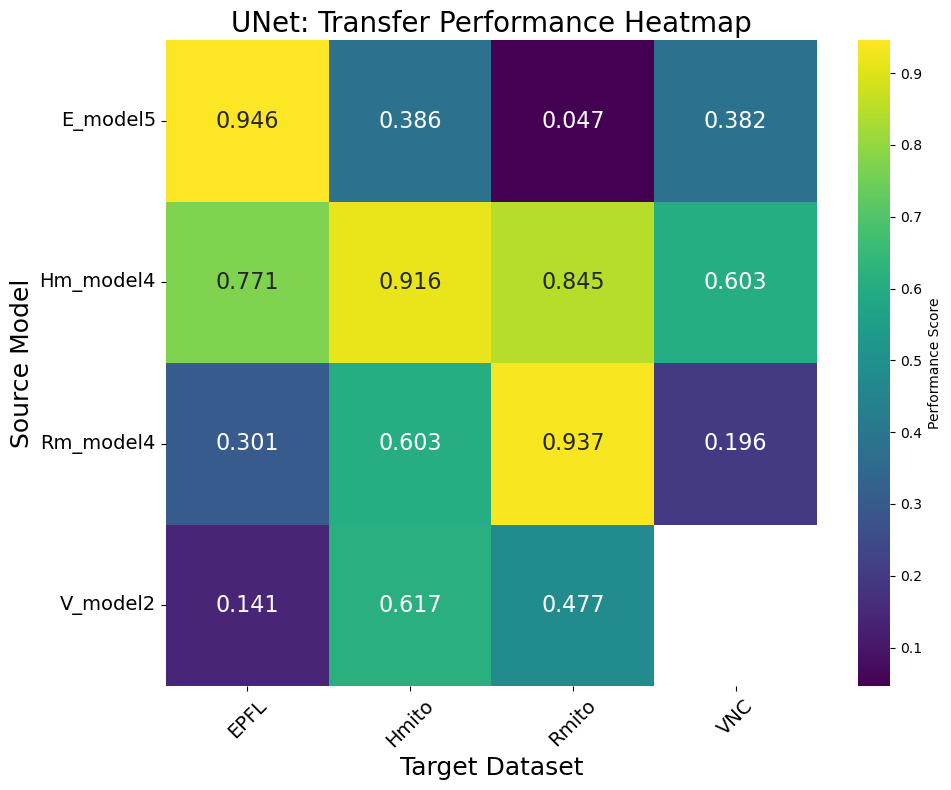

In [13]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    _, _, NA_perf = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models=source_models,
        selected_augmentations={"none": []},
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    if target == "VNC":
        NA_perf_scores = np.append(NA_perf_scores, np.nan)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets,
    title_prefix="UNet:"
)